# Análisis de Portafolio Personal
**Mateo Gómez Macías**  
**Fecha:** Mayo 2026

---

Este notebook analiza el portafolio personal compuesto por:
**MSFT, LLY, MA, BRK-B, NU, NUVL, WMT, CVX**

El análisis se estructura en 7 secciones:
1. Parámetros Globales
2. Análisis Fundamental
3. Matriz de Correlación
4. Optimización de Portafolios
5. Backtesting Dinámico
6. Métricas de Desempeño (incluyendo Upside/Downside Capture)
7. Pesos Finales y Selección de Estrategia

## 0. Librerías e Imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

## 1. Parámetros Globales

Definimos los tickers del portafolio, el período de análisis y la tasa libre de riesgo (Fed Funds Rate actual: 3.75%).

In [2]:
start   = '2022-05-01'
end     = '2026-05-21'
rf      = 0.0375
tickers = ['MSFT', 'LLY', 'MA', 'BRK-B', 'NU', 'NUVL', 'WMT', 'CVX']

In [3]:
prices    = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']
benchmark = yf.download('SPY',   start=start, end=end, auto_adjust=True)['Close']
rets      = prices.pct_change().dropna()

print(f'Activos descargados: {prices.shape[1]}')
print(f'Período: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Días de trading: {prices.shape[0]}')
prices.tail(3)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed

Activos descargados: 8
Período: 2022-05-02 → 2026-05-20
Días de trading: 1017


Ticker,BRK-B,CVX,LLY,MA,MSFT,NU,NUVL,WMT
Date,,,,,,,,
2026-05-18,488.380005,194.339996,988.090027,505.790009,423.540009,12.29,99.900002,133.339996
2026-05-19,480.459991,197.250000,1021.409973,499.700012,417.420013,12.29,101.000000,134.199997
2026-05-20,480.899994,191.330002,1018.869995,498.040009,421.059998,12.79,102.320000,130.850006


## 2. Análisis Fundamental

Para cada acción calculamos las métricas fundamentales clave:

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **EPS** | Net Income / Shares | Ganancia por acción |
| **PER** | Precio / EPS | Cuánto paga el mercado por cada $1 de ganancia |
| **GPM** | Gross Profit / Revenue × 100 | Eficiencia operativa |
| **ROE** | Net Income / Equity × 100 | Retorno sobre capital propio |
| **PBV** | Market Cap / Book Value | Prima sobre valor contable |
| **Solvencia** | Total Assets / Current Liabilities | Capacidad de pago |

> **Nota:** NUVL es empresa pre-revenue — las métricas tradicionales no aplican. Se usa Cash Runway como indicador de solidez financiera.

In [4]:
def get_historical_price(ticker, date):
    end_d = date + dt.timedelta(days=4)
    df    = yf.Ticker(ticker).history(start=date, end=end_d)
    return df['Close'].iloc[0] if not df.empty else np.nan

In [5]:
fundamental_data = {}

for ticker in tickers:
    print(f'  Procesando {ticker}...')
    try:
        obj           = yf.Ticker(ticker)
        estado        = obj.income_stmt
        balance_sheet = obj.balance_sheet
        info_dict     = obj.info

        # EPS
        try:
            eps = (estado.loc['Net Income Common Stockholders'] /
                   balance_sheet.loc['Ordinary Shares Number']).iloc[0]
        except: eps = np.nan

        # PER
        try:
            per = info_dict['currentPrice'] / info_dict['trailingEps']
        except: per = np.nan

        # GPM
        try:
            if ticker == 'NU':
                gpm = (estado.loc['Net Income'].iloc[0] /
                       estado.loc['Total Revenue'].iloc[0]) * 100
            elif ticker == 'NUVL':
                gpm = np.nan
            else:
                gpm = (estado.loc['Gross Profit'].iloc[0] /
                       estado.loc['Total Revenue'].iloc[0]) * 100
        except: gpm = np.nan

        # ROE
        try:
            roe = (estado.loc['Net Income Common Stockholders'].iloc[0] /
                   balance_sheet.loc['Stockholders Equity'].iloc[0]) * 100
        except: roe = np.nan

        # PBV
        try:
            dates   = list(balance_sheet.columns)
            prices_ = [get_historical_price(ticker, d) for d in dates]
            pbv     = ((balance_sheet.loc['Ordinary Shares Number'] * prices_) /
                        balance_sheet.loc['Stockholders Equity']).iloc[0]
        except: pbv = np.nan

        # Solvencia
        try:
            assets = balance_sheet.loc['Total Assets'].iloc[0]
            if ticker in ['NU', 'NUVL']:
                liab = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[0]
            else:
                liab = balance_sheet.loc['Current Liabilities'].iloc[0]
            solvency = assets / liab
        except: solvency = np.nan

        # Cash Runway (solo NUVL)
        if ticker == 'NUVL':
            try:
                cf     = obj.cashflow
                cash   = balance_sheet.loc['Cash Cash Equivalents And Short Term Investments'].iloc[0]
                burn   = abs(cf.loc['Operating Cash Flow'].iloc[0])
                runway = cash / burn
            except: runway = np.nan
        else:
            runway = np.nan

        fundamental_data[ticker] = {
            'EPS ($)'          : round(eps, 2)      if not np.isnan(eps)      else 'N/A',
            'PER (x)'          : round(per, 2)      if not np.isnan(per)      else 'N/A',
            'GPM (%)'          : round(gpm, 2)      if not np.isnan(gpm)      else 'N/A',
            'ROE (%)'          : round(roe, 2)      if not np.isnan(roe)      else 'N/A',
            'PBV (x)'          : round(pbv, 2)      if not np.isnan(pbv)      else 'N/A',
            'Solvencia'        : round(solvency, 2) if not np.isnan(solvency) else 'N/A',
            'Cash Runway (años)': round(runway, 1)  if not np.isnan(runway)   else 'N/A',
        }
    except Exception as e:
        print(f'    Error en {ticker}: {e}')
        fundamental_data[ticker] = {}

fund_df = pd.DataFrame(fundamental_data).T
fund_df

  Procesando MSFT...
  Procesando LLY...
  Procesando MA...
  Procesando BRK-B...
  Procesando NU...
  Procesando NUVL...
  Procesando WMT...
  Procesando CVX...


,EPS ($),PER (x),GPM (%),ROE (%),PBV (x),Solvencia,Cash Runway (años)
MSFT,N/A,24.93,68.82,29.65,10.7,4.38,N/A
LLY,23.07,37.04,83.04,77.78,36.12,3.19,N/A
MA,N/A,28.9,77.89,193.46,65.76,2.38,N/A
BRK-B,N/A,14.29,N/A,9.33,0.0,N/A,N/A
NU,N/A,20.25,27.0,25.41,7.2,1.18,N/A
NUVL,-5.44,-16.71,N/A,-34.08,6.3,8.59,5.0
WMT,2.75,42.73,24.93,21.98,9.89,2.65,N/A
CVX,N/A,33.22,30.41,6.6,1.59,9.7,N/A


## 3. Matriz de Correlación

La correlación mide qué tan relacionados están los movimientos de precio entre activos.

- **Cercana a 1** → se mueven juntos (mala diversificación)
- **Cercana a 0** → se mueven de forma independiente (buena diversificación)
- **Cercana a -1** → se mueven en direcciones opuestas (cobertura perfecta)

Un portafolio bien diversificado busca correlaciones bajas entre activos para reducir el riesgo sin sacrificar rendimiento.

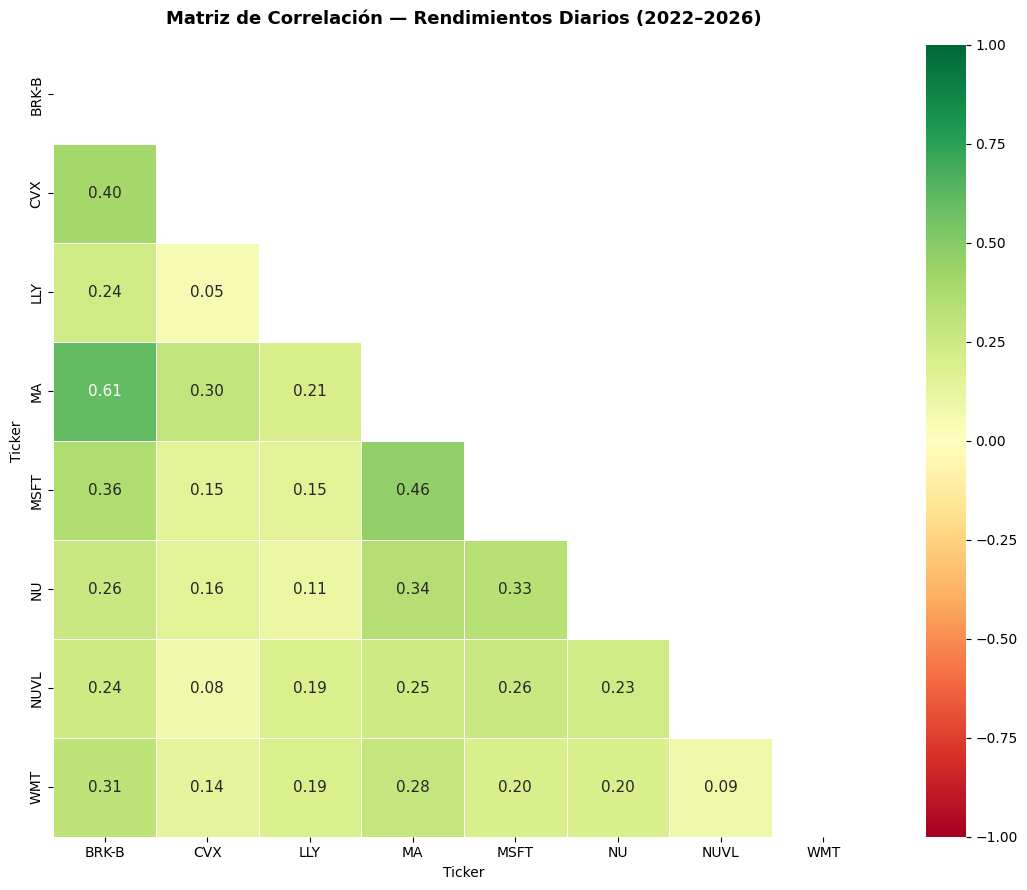

In [6]:
corr = rets.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 11}
)
ax.set_title('Matriz de Correlación — Rendimientos Diarios (2022–2026)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 4. Optimización de Portafolios

Implementamos 4 estrategias de optimización:

| Estrategia | Objetivo | Perfil |
|------------|----------|--------|
| **Mínima Varianza** | Minimizar volatilidad total | Conservador |
| **Máximo Sharpe** | Maximizar rendimiento ajustado por riesgo | Moderado |
| **Mínima Semivarianza** | Minimizar solo la volatilidad negativa | Moderado-conservador |
| **Máximo Omega** | Maximizar captura de alzas vs caídas | Agresivo |

> **Restricción:** Ningún activo puede superar el **30%** del portafolio para evitar concentración excesiva.

In [19]:
class OptimizePortfolioWeights:

    def __init__(self, returns, risk_free):
        self.rets = returns
        self.cov  = returns.cov()
        self.rf   = risk_free / 252
        self.n    = len(returns.columns)

    def _base(self, fun):
        return minimize(
            fun,
            np.ones(self.n) / self.n,
            bounds=[(0.08, 0.30)] * self.n,
            constraints={'fun': lambda w: sum(w) - 1, 'type': 'eq'},
            tol=1e-16
        ).x

    def opt_min_var(self):
        return self._base(lambda w: w.T @ self.cov @ w)

    def opt_max_sharpe(self):
        rend, cov, rf = self.rets.mean(), self.cov, self.rf
        return self._base(
            lambda w: -((np.dot(rend, w) - rf) /
                        (w.reshape(-1,1).T @ cov @ w) ** 0.5)
        )

    def opt_min_semivar(self, rets_bench):
        diffs  = self.rets - rets_bench.values
        below  = diffs[diffs < 0].fillna(0)
        td     = np.array(below.std())
        sm     = np.multiply(td.reshape(len(td), 1), td) * self.rets.corr()
        return self._base(lambda w: w.T @ sm @ w)

    def opt_max_omega(self, rets_bench):
        diffs = self.rets - rets_bench.values
        below = diffs[diffs < 0].fillna(0)
        above = diffs[diffs > 0].fillna(0)
        o     = np.array(above.std()) / np.array(below.std())
        return self._base(lambda w: -sum(o * w))

## 5. Backtesting Dinámico

El backtesting dinámico reoptimiza los pesos del portafolio cada **12 meses** con datos históricos disponibles hasta ese momento, simulando cómo hubiera funcionado la estrategia en el pasado.

**Capital inicial simulado:** $1,000,000 USD  
**Benchmark:** SPY (S&P 500 pasivo)

> ⏳ Este proceso puede tardar 1–2 minutos.

In [20]:
class DynamicBacktesting:

    def __init__(self, prices, bench, capital, rf, months):
        self.prices  = prices
        self.bench   = bench
        self.months  = months
        self.capital = capital
        self.rf      = rf

    def _get_weights(self, prices, n_days, period):
        td  = prices.iloc[int(n_days*period):int(n_days*(period+1))]
        tb  = self.bench.loc[td.index[0]:td.index[-1]]
        opt = OptimizePortfolioWeights(td.pct_change().dropna(), self.rf)
        rb  = tb.pct_change().dropna()
        return (opt.opt_min_var(), opt.opt_max_sharpe(),
                opt.opt_min_semivar(rb), opt.opt_max_omega(rb))

    def simulation(self):
        n_days = round(len(self.prices) /
                       round(len(self.prices)/252/(self.months/12)), 0)
        cap    = self.capital
        opt_d  = self.prices.iloc[:int(n_days)]
        bt_d   = self.prices.iloc[int(n_days):]
        bt_r   = bt_d.pct_change().dropna()

        day_c, per_c = 0, 0
        mv = [cap]; sh = [cap]; sv = [cap]; om = [cap]
        w_mv, w_sh, w_sv, w_om = self._get_weights(opt_d, n_days, 0)

        for day in range(len(bt_d) - 1):
            r = bt_r.iloc[day]
            if day_c >= n_days:
                w_mv, w_sh, w_sv, w_om = self._get_weights(bt_d, n_days, per_c)
                per_c += 1; day_c = 0
            mv.append(mv[-1] * (1 + sum(r * w_mv)))
            sh.append(sh[-1] * (1 + sum(r * w_sh)))
            sv.append(sv[-1] * (1 + sum(r * w_sv)))
            om.append(om[-1] * (1 + sum(r * w_om)))
            day_c += 1

        df            = pd.DataFrame(index=bt_d.index)
        df['Min Var'] = mv
        df['Sharpe']  = sh
        df['Semivar'] = sv
        df['Omega']   = om
        return df

In [21]:
print('Corriendo backtesting dinámico...')
history = DynamicBacktesting(prices, benchmark, 1_000_000, rf, 12).simulation()

# Agregar SPY como benchmark pasivo
br  = benchmark.pct_change().dropna()
br  = br[br.index >= history.index[0]]
bc  = (br + 1).cumprod() / (br + 1).cumprod().iloc[0]
history['SPY (Pasivo)'] = 1_000_000 * bc.values

print('Backtesting completado.')
history.tail(3)

Corriendo backtesting dinámico...
Backtesting completado.


,Min Var,Sharpe,Semivar,Omega,SPY (Pasivo)
Date,,,,,
2026-05-18,2.075736e+06,2.236036e+06,1.804140e+06,2.418103e+06,1.860222e+06
2026-05-19,2.073325e+06,2.238595e+06,1.798615e+06,2.430681e+06,1.847831e+06
2026-05-20,2.069048e+06,2.226782e+06,1.800625e+06,2.429681e+06,1.866770e+06


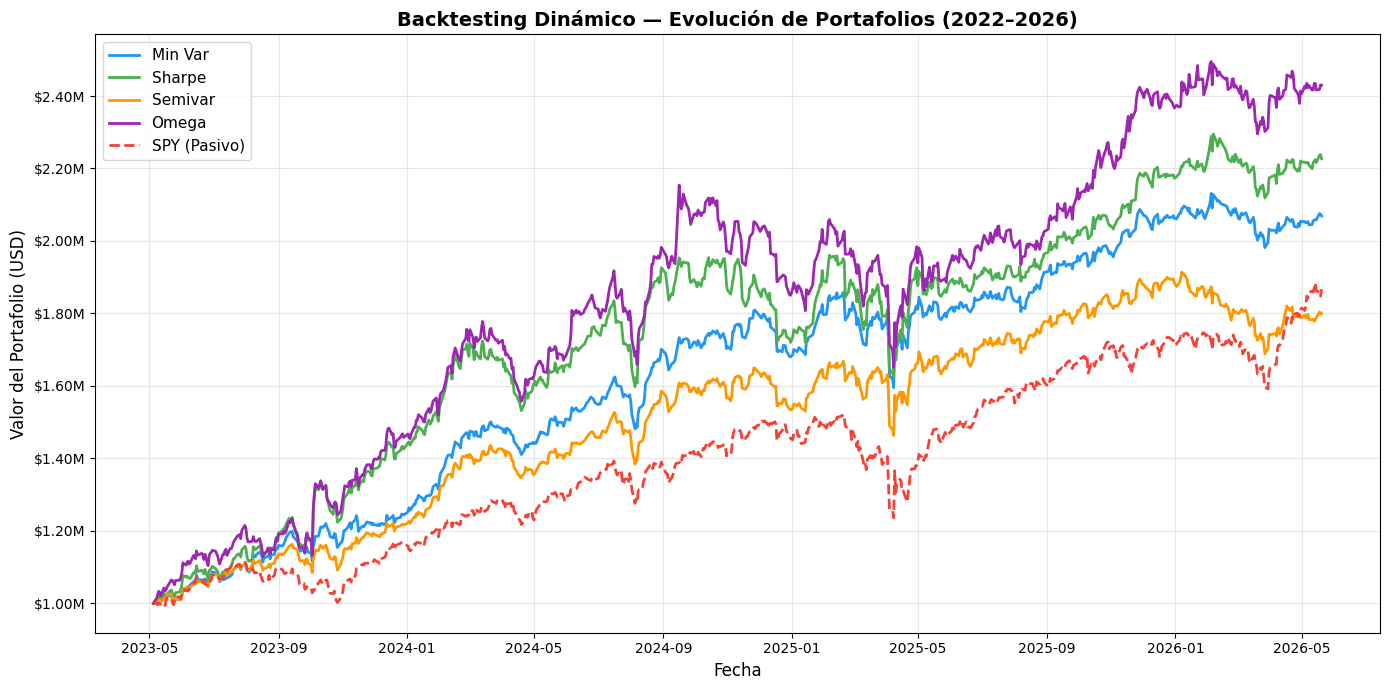

In [22]:
colors = {
    'Min Var'     : '#2196F3',
    'Sharpe'      : '#4CAF50',
    'Semivar'     : '#FF9800',
    'Omega'       : '#9C27B0',
    'SPY (Pasivo)': '#F44336'
}

fig, ax = plt.subplots(figsize=(14, 7))
for col, color in colors.items():
    ls = '--' if col == 'SPY (Pasivo)' else '-'
    ax.plot(history.index, history[col], label=col,
            color=color, linewidth=2, linestyle=ls)

ax.set_title('Backtesting Dinámico — Evolución de Portafolios (2022–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor del Portafolio (USD)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.2f}M'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Métricas de Desempeño

Calculamos las métricas estándar más una métrica nueva clave para tu perfil:

| Métrica | Fórmula | Qué mide |
|---------|---------|----------|
| **Sharpe Ratio** | (Rend - Rf) / Vol | Rendimiento por unidad de riesgo total |
| **Sortino Ratio** | (Rend - Rf) / Vol Downside | Igual pero solo penaliza volatilidad negativa |
| **Beta** | Cov(Port, SPY) / Var(SPY) | Sensibilidad al mercado |
| **Alpha Jensen** | Rend - [Rf + β(Rend_SPY - Rf)] | Valor generado sobre el benchmark |
| **Upside Capture** | Rend_Port(días+) / Rend_SPY(días+) | % de las alzas del mercado que captura |
| **Downside Capture** | Rend_Port(días-) / Rend_SPY(días-) | % de las caídas del mercado que sufre |
| **Capture Ratio** | Upside / Downside | Ideal: > 1 (captura más alzas que caídas) |

In [23]:
rets_h     = history.pct_change().dropna()
rend_anual = rets_h.mean() * 252
vol_anual  = rets_h.std()  * np.sqrt(252)
sharpe_r   = (rend_anual - rf) / vol_anual

# Sortino
rets_dn   = rets_h[rets_h < 0].fillna(0)
vol_dn    = rets_dn.std() * np.sqrt(252)
sortino_r = (rend_anual - rf) / vol_dn

print('Métricas base calculadas.')

Métricas base calculadas.


In [24]:
# Beta, Treynor, Alpha de Jensen
spy_r = rets_h['SPY (Pasivo)']
betas, treynor, alphas = {}, {}, {}

for col in ['Min Var', 'Sharpe', 'Semivar', 'Omega']:
    b              = np.cov(rets_h[col], spy_r)[0,1] / np.var(spy_r)
    betas[col]     = b
    treynor[col]   = (rend_anual[col] - rf) / b
    alphas[col]    = rend_anual[col] - (rf + b * (rend_anual['SPY (Pasivo)'] - rf))

betas['SPY (Pasivo)']   = 1.0
treynor['SPY (Pasivo)'] = (rend_anual['SPY (Pasivo)'] - rf) / 1.0
alphas['SPY (Pasivo)']  = 0.0

betas   = pd.Series(betas)
treynor = pd.Series(treynor)
alphas  = pd.Series(alphas)

print('Beta, Treynor y Alpha calculados.')

Beta, Treynor y Alpha calculados.


In [25]:
# Upside / Downside Capture Ratio
up_cap, dn_cap = {}, {}

for col in ['Min Var', 'Sharpe', 'Semivar', 'Omega']:
    up_days = spy_r > 0
    dn_days = spy_r < 0
    up_cap[col] = (rets_h[col][up_days].mean() / spy_r[up_days].mean()) * 100
    dn_cap[col] = (rets_h[col][dn_days].mean() / spy_r[dn_days].mean()) * 100

up_cap['SPY (Pasivo)'] = 100.0
dn_cap['SPY (Pasivo)'] = 100.0

up_cap    = pd.Series(up_cap)
dn_cap    = pd.Series(dn_cap)
cap_ratio = up_cap / dn_cap

print('Upside/Downside Capture calculado.')

Upside/Downside Capture calculado.


In [26]:
# Tabla resumen completa
resumen = pd.DataFrame({
    'Capital Inicial ($)' : history.iloc[0],
    'Capital Final ($)'   : history.iloc[-1],
    'Rend. Anual %'       : (rend_anual * 100).round(2),
    'Vol. Anual %'        : (vol_anual  * 100).round(2),
    'Sharpe Ratio'        : sharpe_r.round(4),
    'Sortino Ratio'       : sortino_r.round(4),
    'Beta'                : betas.round(4),
    'Treynor'             : treynor.round(4),
    'Alpha Jensen %'      : (alphas * 100).round(2),
    'Upside Capture %'    : up_cap.round(2),
    'Downside Capture %'  : dn_cap.round(2),
    'Capture Ratio'       : cap_ratio.round(4),
}).T

resumen

,Min Var,Sharpe,Semivar,Omega,SPY (Pasivo)
Capital Inicial ($),1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06,1.000000e+06
Capital Final ($),2.069048e+06,2.226782e+06,1.800625e+06,2.429681e+06,1.866770e+06
Rend. Anual %,2.502000e+01,2.820000e+01,2.043000e+01,3.158000e+01,2.178000e+01
Vol. Anual %,1.393000e+01,1.857000e+01,1.400000e+01,2.113000e+01,1.509000e+01
Sharpe Ratio,1.527500e+00,1.316400e+00,1.191900e+00,1.317000e+00,1.194800e+00
Sortino Ratio,2.625900e+00,2.346100e+00,2.005300e+00,2.471800e+00,2.000400e+00
Beta,6.654000e-01,7.840000e-01,7.305000e-01,8.443000e-01,1.000000e+00
Treynor,3.197000e-01,3.119000e-01,2.284000e-01,3.297000e-01,1.803000e-01
Alpha Jensen %,9.270000e+00,1.031000e+01,3.510000e+00,1.261000e+01,0.000000e+00
Upside Capture %,6.795000e+01,8.620000e+01,7.508000e+01,9.887000e+01,1.000000e+02


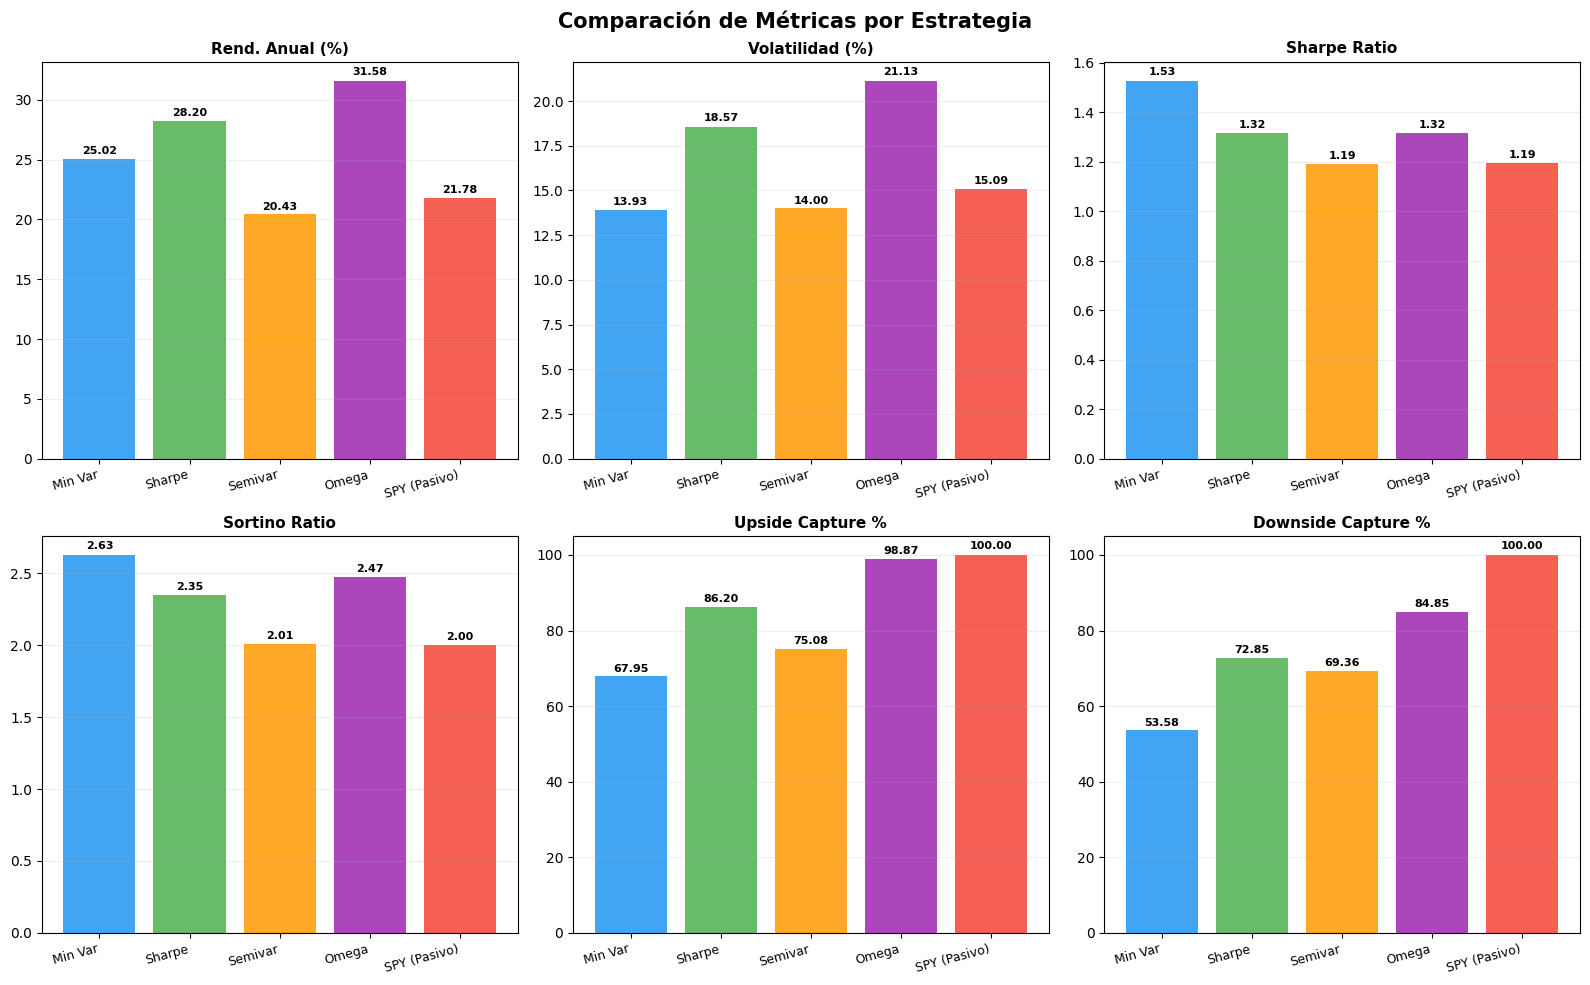

In [27]:
# Gráficas comparativas de métricas
estrategias  = ['Min Var', 'Sharpe', 'Semivar', 'Omega', 'SPY (Pasivo)']
colores_bar  = [colors[e] for e in estrategias]

metricas_plot = {
    'Rend. Anual (%)'    : rend_anual * 100,
    'Volatilidad (%)'    : vol_anual  * 100,
    'Sharpe Ratio'       : sharpe_r,
    'Sortino Ratio'      : sortino_r,
    'Upside Capture %'   : up_cap,
    'Downside Capture %' : dn_cap,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparación de Métricas por Estrategia', fontsize=15, fontweight='bold')

for ax, (nombre, serie) in zip(axes.flat, metricas_plot.items()):
    vals = [serie[e] for e in estrategias]
    bars = ax.bar(estrategias, vals, color=colores_bar, alpha=0.85)
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xticklabels(estrategias, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()*1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

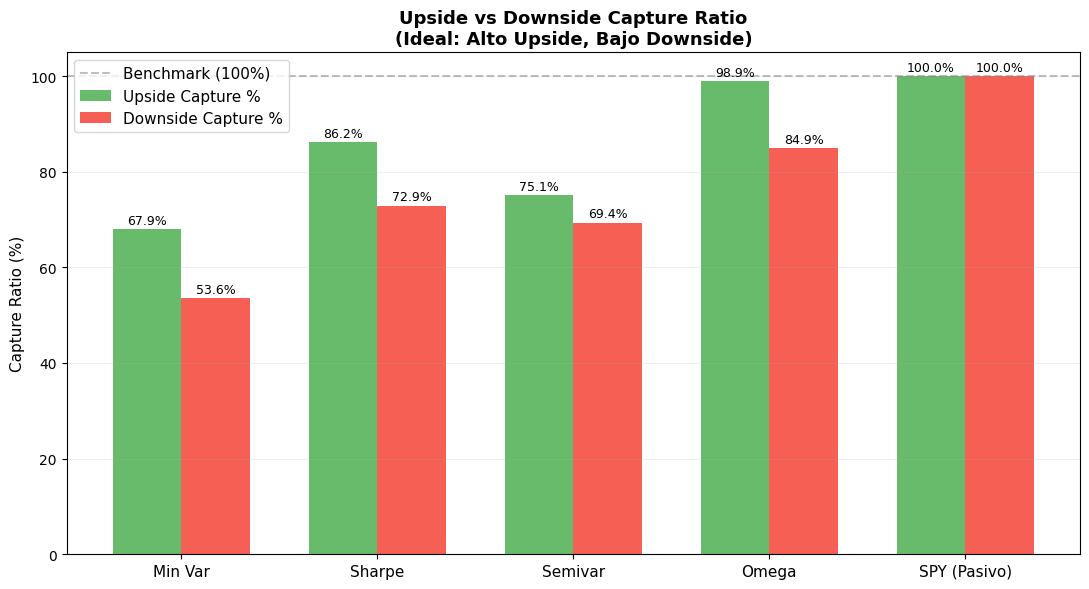

In [28]:
# Upside vs Downside Capture
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(estrategias))
w = 0.35

bars1 = ax.bar(x - w/2, [up_cap[e] for e in estrategias], w,
               label='Upside Capture %', color='#4CAF50', alpha=0.85)
bars2 = ax.bar(x + w/2, [dn_cap[e] for e in estrategias], w,
               label='Downside Capture %', color='#F44336', alpha=0.85)

ax.set_title('Upside vs Downside Capture Ratio\n(Ideal: Alto Upside, Bajo Downside)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(estrategias, fontsize=11)
ax.set_ylabel('Capture Ratio (%)', fontsize=11)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Benchmark (100%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Pesos Finales y Selección de Estrategia

Calculamos los pesos óptimos usando datos del **último año** (mayo 2025 – mayo 2026), que es el período más relevante para las decisiones actuales.

### Criterio de selección para perfil neutral-agresivo:

| Criterio | Peso en decisión |
|----------|------------------|
| Sharpe Ratio alto | Rendimiento ajustado por riesgo |
| Upside Capture alto | Captura las alzas del mercado |
| Downside Capture bajo | No sufre tanto las caídas |
| Volatilidad aceptable | No excesiva para el perfil |

> La estrategia ganadora no es necesariamente la de mayor rendimiento sino la que mejor equilibra estas 4 condiciones.

In [29]:
pr = yf.download(tickers, start='2025-05-21', end='2026-05-21', auto_adjust=True)['Close']
br = yf.download('SPY',   start='2025-05-21', end='2026-05-21', auto_adjust=True)['Close']

rr    = pr.pct_change().dropna()
rb    = br.pct_change().dropna()
opt_f = OptimizePortfolioWeights(rr, rf)

w_mv = opt_f.opt_min_var()
w_sh = opt_f.opt_max_sharpe()
w_sv = opt_f.opt_min_semivar(rb)
w_om = opt_f.opt_max_omega(rb)

pesos_df = pd.DataFrame({
    'Ticker'       : pr.columns.tolist(),
    'Min Var %'    : (w_mv * 100).round(2),
    'Max Sharpe %' : (w_sh * 100).round(2),
    'Semivar %'    : (w_sv * 100).round(2),
    'Omega %'      : (w_om * 100).round(2),
    'Precio Actual': pr.iloc[-1].values.round(2),
})

pesos_df

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed


,Ticker,Min Var %,Max Sharpe %,Semivar %,Omega %,Precio Actual
0,BRK-B,20.82,8.0,17.43,8.0,480.90
1,CVX,20.96,30.0,17.78,8.0,191.33
2,LLY,8.00,8.0,8.00,8.0,1018.87
3,MA,8.00,8.0,8.00,8.0,498.04
4,MSFT,12.89,8.0,15.22,8.0,421.06
5,NU,8.00,8.0,8.00,8.0,12.79
6,NUVL,8.00,8.0,8.00,22.0,102.32
7,WMT,13.33,22.0,17.57,30.0,130.85


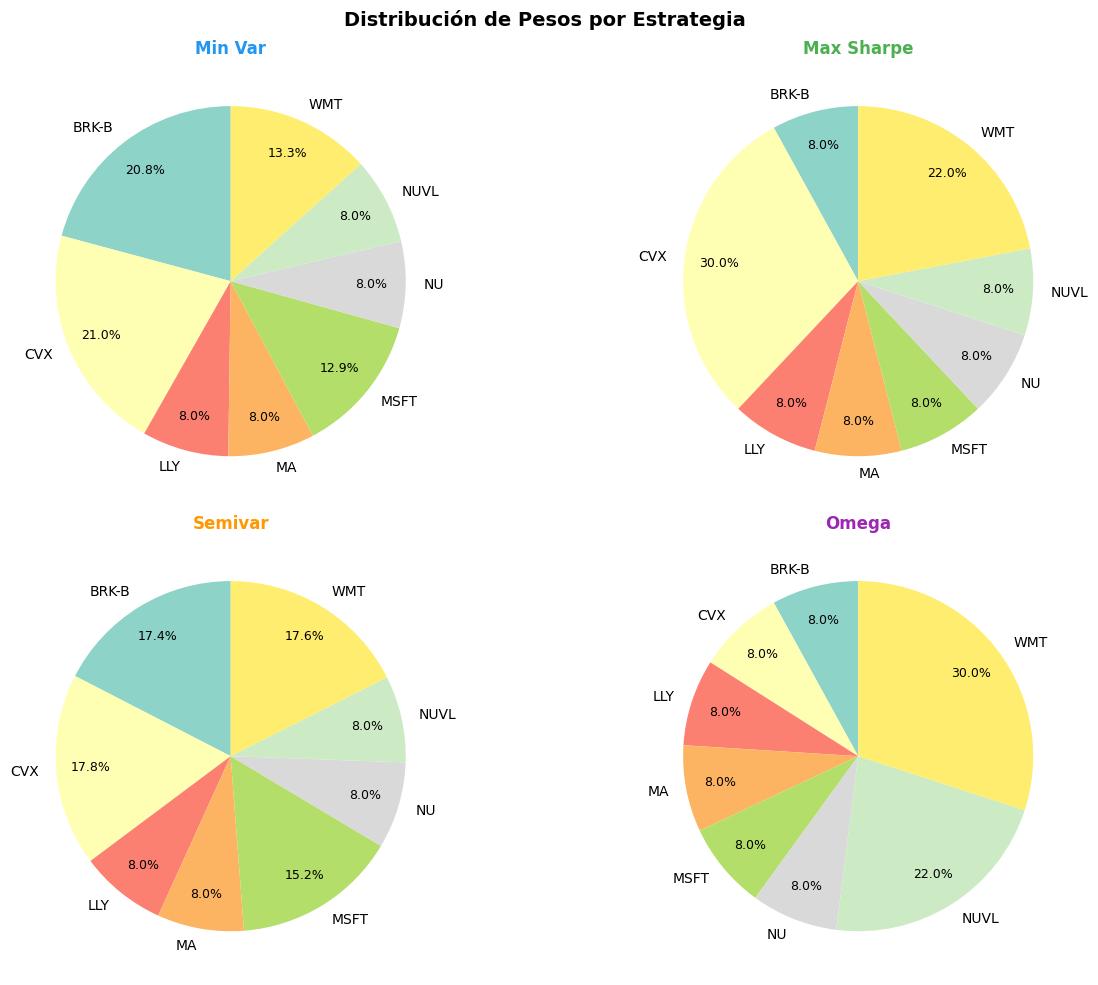

In [30]:
# Gráficos de pesos por estrategia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Pesos por Estrategia', fontsize=14, fontweight='bold')

estrategias_w = [
    ('Min Var',    w_mv, '#2196F3'),
    ('Max Sharpe', w_sh, '#4CAF50'),
    ('Semivar',    w_sv, '#FF9800'),
    ('Omega',      w_om, '#9C27B0'),
]

for ax, (nombre, pesos, color) in zip(axes.flat, estrategias_w):
    wedges, _, autotexts = ax.pie(
        pesos,
        labels=pr.columns.tolist(),
        autopct='%1.1f%%',
        colors=plt.cm.Set3(np.linspace(0, 1, len(pesos))),
        startangle=90,
        pctdistance=0.8
    )
    for a in autotexts:
        a.set_fontsize(9)
    ax.set_title(nombre, fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## 8. Conclusión y Selección Final

Completa esta sección una vez que hayas corrido el notebook y veas los resultados.

### Framework de decisión:

**Para perfil neutral-agresivo con horizonte largo:**

1. ¿Cuál estrategia tiene el **Sharpe más alto**?
2. ¿Cuál tiene el **Upside Capture más alto** con **Downside Capture razonable**?
3. ¿La volatilidad de la estrategia ganadora es **aceptable para ti emocionalmente**?

Si la respuesta a las 3 preguntas apunta a la misma estrategia → esa es tu elección.  
Si hay conflicto → prioriza Capture Ratio sobre rendimiento absoluto.

---

**Estrategia seleccionada:** *(completar después de ver resultados)*  
**Justificación:** *(completar con los números reales)*